# Asset Allocation Performance Forecasting Challenge
## ENS Data Challenge — QRT

## Group Members
- Nour Salhi
- Rawad Hamouche
- Tom CHASSAGNE
- Nada LABRAIMI

## Project Context
This notebook presents our solution for the ENS Challenge Data finance project (Challenge #167).
The objective is to predict the **direction** (sign) of the next-day return of an asset allocation
using historical return, volume, turnover and group information.

The project is submitted as a fully running Colab notebook, following the course instructions.


In [6]:
# ============================================================
# IMPORTS
# ============================================================
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier, VotingClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

try:
    from lightgbm import LGBMClassifier
    LIGHTGBM_AVAILABLE = True
    print("LightGBM available: True")
except Exception:
    LIGHTGBM_AVAILABLE = False
    print("LightGBM available: False")

try:
    from xgboost import XGBClassifier
    XGBOOST_AVAILABLE = True
    print("XGBoost available: True")
except Exception:
    XGBOOST_AVAILABLE = False
    print("XGBoost available: False")

RANDOM_STATE = 42


LightGBM available: True
XGBoost available: True


## 1. Introduction

### 1.1 Background and Motivation
In systematic trading, asset allocations are ubiquitous — but signal quality makes all the difference.
Every day, traders face a flood of candidate allocations: portfolio constructions built on recent
predictive signals, liquidity flows, or historical patterns. Some will be profitable in the next
trading session. Others will underperform — or lose so consistently that betting *against* them
is the most profitable strategy.

### 1.2 Challenge Objective
This challenge, proposed by **QRT (Qube Research & Technologies)**, centres on a simple but
crucial question:

> *Can you predict whether a given asset allocation deserves to be followed — or whether it is
> better to bet against it?*

Formally, the task is a **binary classification problem**:
- **1** → predict a positive next-day return → *trust* the allocation
- **0** → predict a negative next-day return → *short* the allocation

### 1.3 Research Questions
1. Do historical returns (lags 1–20) contain predictive signal for next-day direction?
2. Does signed volume carry additional information beyond returns?
3. Does turnover influence predictability?
4. Are there group-level effects that can be exploited?

### 1.4 Report Structure
The notebook follows the structure: Dataset Description → EDA → Feature Engineering →
Methodology → Model Development → Results → Ensemble → Conclusion.


## 2. Load Data

Upload the following files to your Colab session before running:
- `X_train_9xQjqvZ.csv`
- `y_train_Ppwhaz8.csv`
- `X_test_1zTtEnD.csv`
- `sample_submission_SpGVFuH.csv`


In [7]:
# ============================================================
# LOAD DATA FROM GOOGLE DRIVE
# ============================================================
import gc
from google.colab import drive
drive.mount('/content/drive')

path = '/content/drive/MyDrive/project/'

X_train = pd.read_csv(path + 'X_train_9xQjqvZ.csv')
y_train = pd.read_csv(path + 'y_train_Ppwhaz8.csv')
X_test  = pd.read_csv(path + 'X_test_1zTtEnD.csv')
sample_submission = pd.read_csv(path + 'sample_submission_SpGVFuH.csv')

for df in [X_train, X_test]:
    for col in df.select_dtypes('float64').columns:
        df[col] = df[col].astype('float32')
gc.collect()

print('X_train :', X_train.shape)
print('y_train :', y_train.shape)
print('X_test  :', X_test.shape)

y_binary = (y_train['target'] > 0).astype(int)
print('Target: 1=Positive', str(round(y_binary.mean()*100,1)) + '% / 0=Negative', str(round((1-y_binary.mean())*100,1)) + '%')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
X_train : (527073, 45)
y_train : (527073, 2)
X_test  : (31870, 45)
Target: 1=Positive 50.7% / 0=Negative 49.3%


## 3. Dataset Description

### 3.1 Dataset Overview
The dataset is provided by **QRT**, a leading quantitative investment firm.
It contains historical financial data for **278 anonymous asset allocations**
observed over **2,522 trading days**, giving **527,073 training observations**
and **31,870 test observations**.

Each row corresponds to one allocation on one specific trading day.
The dataset has a **multi-index structure** (date × allocation).

| File | Rows | Description |
|------|------|-------------|
| X_train | 527,073 | Training features |
| y_train | 527,073 | Continuous target returns |
| X_test  | 31,870  | Test features (no target) |

### 3.2 Data Structure and Multi-Index Format
Each observation is uniquely identified by `ROW_ID`, which maps a `(TS, ALLOCATION)` tuple.
Dates are anonymised (DATE_0001, DATE_0002, …) with **no guarantee of continuity**.

### 3.3 Description of Variables


In [8]:
# ============================================================
# 3.3 Variable Description
# ============================================================
var_desc = pd.DataFrame([
    ['ROW_ID',                   'int',        'Unique row identifier mapping (TS, ALLOCATION)'],
    ['TS',                       'str',        'Anonymised trading date (DATE_0001, DATE_0002, …)'],
    ['ALLOCATION',               'str',        'Anonymised allocation name (ALLOCATION_01, …)'],
    ['GROUP',                    'int',        'Anonymised group the allocation belongs to (1–4)'],
    ['RET_1 … RET_20',           'float',      'Daily return of the allocation i days ago (RET_1 = yesterday)'],
    ['SIGNED_VOLUME_1 … _20',    'float',      'Weighted signed market volume i days ago (∑ w·V, rescaled)'],
    ['MEDIAN_DAILY_TURNOVER',    'float',      'Median daily turnover over last 20 days: median(∑|w_t - w_{t-1}|)'],
    ['TARGET (y_train)',         'float',      'Next-day return of the allocation (to predict)'],
], columns=['Variable', 'Type', 'Description'])
display(var_desc)

print(f"\nUnique allocations : {X_train['ALLOCATION'].nunique()}")
print(f"Unique dates (TS)  : {X_train['TS'].nunique()}")
print(f"Groups             : {sorted(X_train['GROUP'].unique())}")
print(f"Total observations : {len(X_train):,}")


,Variable,Type,Description
0,ROW_ID,int,"Unique row identifier mapping (TS, ALLOCATION)"
1,TS,str,"Anonymised trading date (DATE_0001, DATE_0002, …)"
2,ALLOCATION,str,"Anonymised allocation name (ALLOCATION_01, …)"
3,GROUP,int,Anonymised group the allocation belongs to (1–4)
4,RET_1 … RET_20,float,Daily return of the allocation i days ago (RET...
5,SIGNED_VOLUME_1 … _20,float,Weighted signed market volume i days ago (∑ w·...
6,MEDIAN_DAILY_TURNOVER,float,Median daily turnover over last 20 days: media...
7,TARGET (y_train),float,Next-day return of the allocation (to predict)



Unique allocations : 278
Unique dates (TS)  : 2522
Groups             : [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
Total observations : 527,073


### 3.4 Data Quality Assessment

Columns with missing values:


,Missing Count,Missing %
SIGNED_VOLUME_1,387506,73.52
SIGNED_VOLUME_20,8498,1.61
MEDIAN_DAILY_TURNOVER,3638,0.69
SIGNED_VOLUME_19,3002,0.57
SIGNED_VOLUME_18,859,0.16
SIGNED_VOLUME_15,42,0.01
SIGNED_VOLUME_16,50,0.01
RET_17,34,0.01
RET_20,58,0.01
RET_19,50,0.01


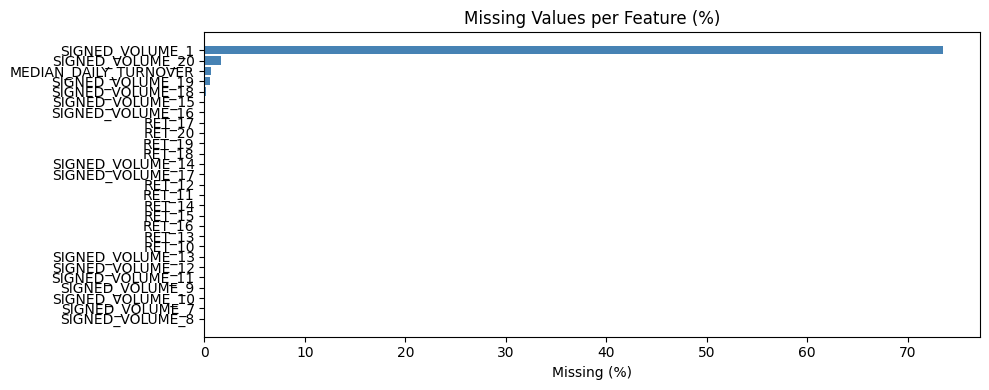


⚠ Key finding: SIGNED_VOLUME_1 is missing for 73.5% of observations.
   This is a structural issue — this column must be excluded or imputed with care.
   All return features (RET_*) have < 0.01% missing values.


In [9]:
# ============================================================
# 3.4 Missing Values Analysis
# ============================================================
missing       = X_train.isnull().sum()
missing_pct   = (missing / len(X_train) * 100).round(2)
missing_df    = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df    = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)

print("Columns with missing values:")
display(missing_df)

fig, ax = plt.subplots(figsize=(10, 4))
ax.barh(missing_df.index, missing_df['Missing %'], color='steelblue')
ax.set_xlabel('Missing (%)')
ax.set_title('Missing Values per Feature (%)')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print("\n⚠ Key finding: SIGNED_VOLUME_1 is missing for 73.5% of observations.")
print("   This is a structural issue — this column must be excluded or imputed with care.")
print("   All return features (RET_*) have < 0.01% missing values.")


## 4. Exploratory Data Analysis

We explore the dataset visually and statistically before modelling.


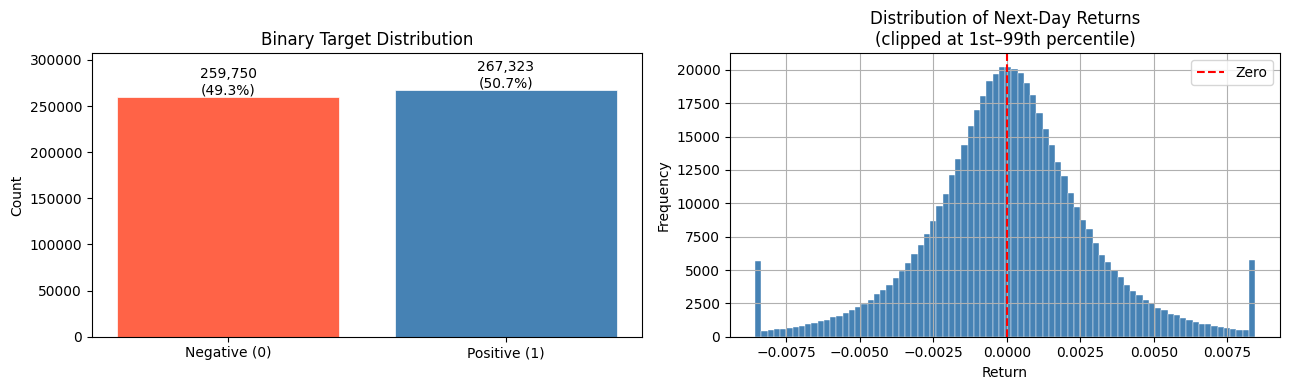

→ Nearly balanced classes: 50.7% positive vs 49.3% negative.
→ Returns are approximately symmetric around 0 with fat tails — typical of financial data.


In [10]:
# ============================================================
# 4.1 Target Distribution
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Binary target
counts = y_binary.value_counts().sort_index()
bars = axes[0].bar(['Negative (0)', 'Positive (1)'], counts.values,
                   color=['tomato', 'steelblue'], edgecolor='white', linewidth=0.5)
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3000,
                 f'{val:,}\n({val/len(y_binary):.1%})', ha='center', fontsize=10)
axes[0].set_title('Binary Target Distribution', fontsize=12)
axes[0].set_ylabel('Count')
axes[0].set_ylim(0, counts.max()*1.15)

# Continuous target
y_train['target'].clip(y_train['target'].quantile(0.01),
                       y_train['target'].quantile(0.99)).hist(bins=80, ax=axes[1],
                       color='steelblue', edgecolor='white', linewidth=0.3)
axes[1].axvline(0, color='red', linestyle='--', linewidth=1.5, label='Zero')
axes[1].set_title('Distribution of Next-Day Returns\n(clipped at 1st–99th percentile)', fontsize=12)
axes[1].set_xlabel('Return')
axes[1].set_ylabel('Frequency')
axes[1].legend()

plt.tight_layout()
plt.show()

print("→ Nearly balanced classes: 50.7% positive vs 49.3% negative.")
print("→ Returns are approximately symmetric around 0 with fat tails — typical of financial data.")


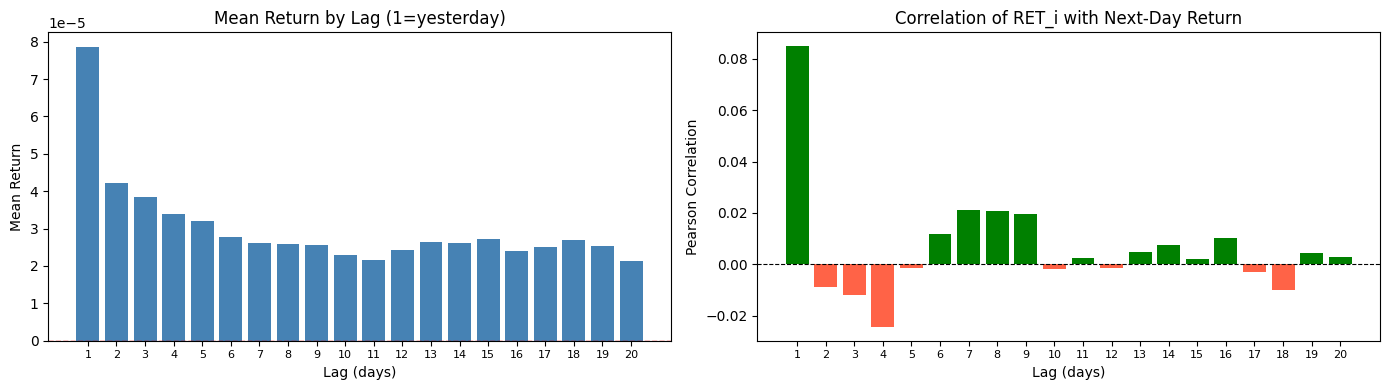

→ RET_1 has the highest positive correlation with target: 0.0849
→ RET_2 to RET_5 show slight negative correlations → short-term mean-reversion signal.
→ Beyond lag 6, correlations are near zero — distant returns carry little signal.


In [11]:
# ============================================================
# 4.2 Historical Return Analysis — Correlation with Target
# ============================================================
ret_cols = [f'RET_{i}' for i in range(1, 21)]
corr_with_target = X_train[ret_cols].corrwith(y_train['target'])

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Mean returns by lag
means = X_train[ret_cols].mean()
axes[0].bar(range(1, 21), means, color='steelblue')
axes[0].axhline(0, color='red', linestyle='--', linewidth=1)
axes[0].set_xticks(range(1, 21))
axes[0].set_xticklabels([f'{i}' for i in range(1,21)], fontsize=8)
axes[0].set_title('Mean Return by Lag (1=yesterday)')
axes[0].set_xlabel('Lag (days)')
axes[0].set_ylabel('Mean Return')

# Correlation with target
colors = ['green' if c > 0 else 'tomato' for c in corr_with_target]
axes[1].bar(range(1, 21), corr_with_target, color=colors)
axes[1].axhline(0, color='black', linestyle='--', linewidth=0.8)
axes[1].set_xticks(range(1, 21))
axes[1].set_xticklabels([f'{i}' for i in range(1,21)], fontsize=8)
axes[1].set_title('Correlation of RET_i with Next-Day Return')
axes[1].set_xlabel('Lag (days)')
axes[1].set_ylabel('Pearson Correlation')

plt.tight_layout()
plt.show()

print(f"→ RET_1 has the highest positive correlation with target: {corr_with_target['RET_1']:.4f}")
print(f"→ RET_2 to RET_5 show slight negative correlations → short-term mean-reversion signal.")
print(f"→ Beyond lag 6, correlations are near zero — distant returns carry little signal.")


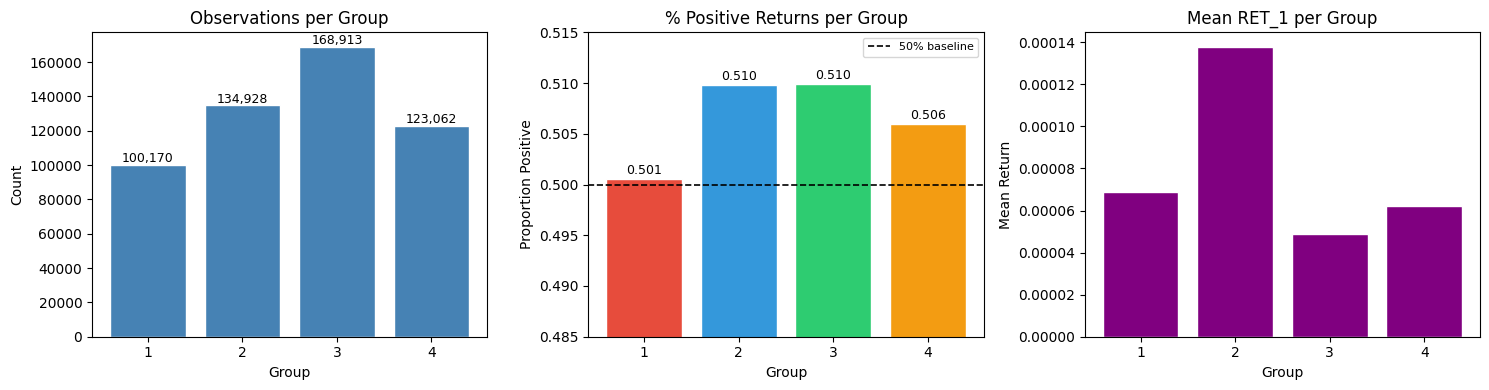

→ Group 3 is the largest (168,913 obs), Group 1 the smallest (100,170 obs).
→ Groups 2 and 3 have slightly higher positive rates (~50.9%) vs Group 1 (~50.0%).
→ GROUP is a useful categorical feature — encodes different allocation strategies.


In [12]:
# ============================================================
# 4.3 Allocation Group Analysis
# ============================================================
df_eda = X_train.copy()
df_eda['y_binary'] = y_binary.values
df_eda['target']   = y_train['target'].values

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Group sizes
gc = df_eda['GROUP'].value_counts().sort_index()
axes[0].bar(gc.index.astype(str), gc.values, color='steelblue', edgecolor='white')
axes[0].set_title('Observations per Group')
axes[0].set_xlabel('Group')
axes[0].set_ylabel('Count')
for g, v in zip(gc.index, gc.values):
    axes[0].text(str(g), v + 1500, f'{v:,}', ha='center', fontsize=9)

# % positive per group
pos_rate = df_eda.groupby('GROUP')['y_binary'].mean()
axes[1].bar(pos_rate.index.astype(str), pos_rate.values,
            color=['#e74c3c','#3498db','#2ecc71','#f39c12'], edgecolor='white')
axes[1].axhline(0.5, color='black', linestyle='--', linewidth=1.2, label='50% baseline')
axes[1].set_ylim(0.485, 0.515)
axes[1].set_title('% Positive Returns per Group')
axes[1].set_xlabel('Group')
axes[1].set_ylabel('Proportion Positive')
axes[1].legend(fontsize=8)
for g, v in pos_rate.items():
    axes[1].text(str(g), v + 0.0005, f'{v:.3f}', ha='center', fontsize=9)

# Mean RET_1 per group
mr = df_eda.groupby('GROUP')['RET_1'].mean()
axes[2].bar(mr.index.astype(str), mr.values, color='purple', edgecolor='white')
axes[2].set_title('Mean RET_1 per Group')
axes[2].set_xlabel('Group')
axes[2].set_ylabel('Mean Return')

plt.tight_layout()
plt.show()

print("→ Group 3 is the largest (168,913 obs), Group 1 the smallest (100,170 obs).")
print("→ Groups 2 and 3 have slightly higher positive rates (~50.9%) vs Group 1 (~50.0%).")
print("→ GROUP is a useful categorical feature — encodes different allocation strategies.")


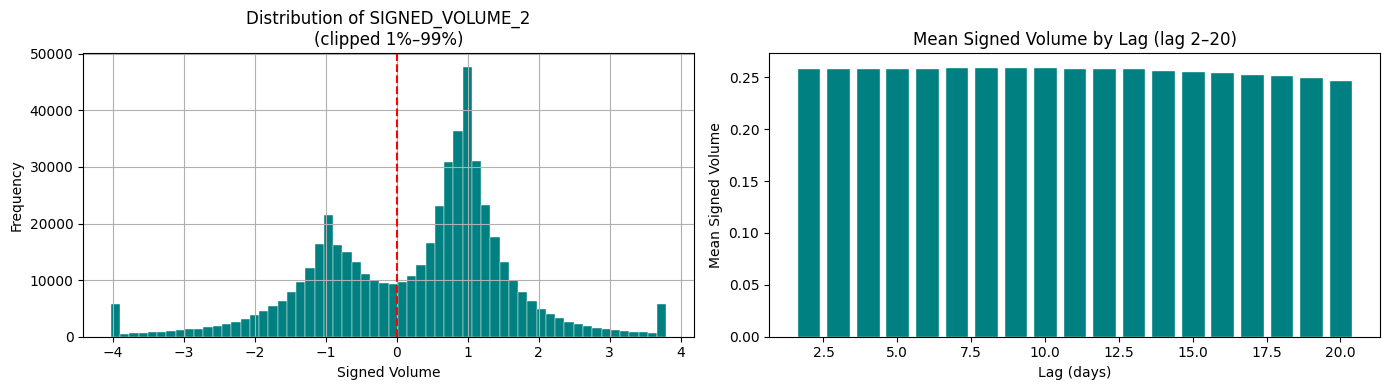

→ SIGNED_VOLUME_1: 73.5% missing → excluded from features.
→ SIGNED_VOLUME_2–20: complete and stable.
→ Signed volumes are right-skewed with positive mean, indicating net buying pressure on average.


In [13]:
# ============================================================
# 4.4 Liquidity Analysis (Signed Volume)
# ============================================================
vol_cols_clean = [f'SIGNED_VOLUME_{i}' for i in range(2, 21)]  # skip SV_1 (73.5% missing)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sv2 = X_train['SIGNED_VOLUME_2'].dropna()
sv2.clip(sv2.quantile(0.01), sv2.quantile(0.99)).hist(bins=60, ax=axes[0],
         color='teal', edgecolor='white', linewidth=0.3)
axes[0].axvline(0, color='red', linestyle='--', linewidth=1.5)
axes[0].set_title('Distribution of SIGNED_VOLUME_2\n(clipped 1%–99%)')
axes[0].set_xlabel('Signed Volume')
axes[0].set_ylabel('Frequency')

vol_means = X_train[vol_cols_clean].mean()
axes[1].bar(range(2, 21), vol_means, color='teal', edgecolor='white')
axes[1].set_title('Mean Signed Volume by Lag (lag 2–20)')
axes[1].set_xlabel('Lag (days)')
axes[1].set_ylabel('Mean Signed Volume')

plt.tight_layout()
plt.show()

print(f"→ SIGNED_VOLUME_1: 73.5% missing → excluded from features.")
print(f"→ SIGNED_VOLUME_2–20: complete and stable.")
print(f"→ Signed volumes are right-skewed with positive mean, indicating net buying pressure on average.")


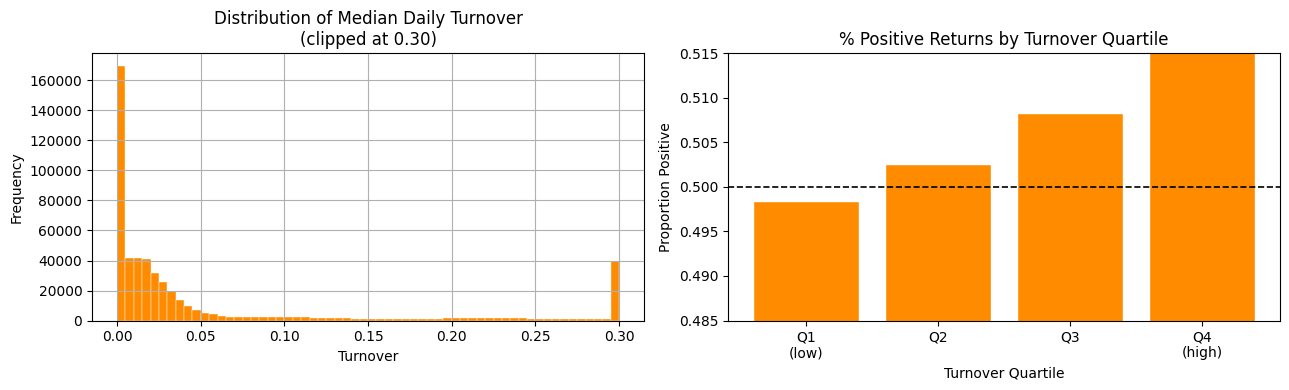

→ Turnover is heavily right-skewed (mean=0.0909, median=0.0159).
→ Log transformation will improve this feature for modelling.
→ Higher turnover allocations show slightly different positive return rates.


In [14]:
# ============================================================
# 4.5 Turnover Analysis
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

to = X_train['MEDIAN_DAILY_TURNOVER'].dropna()
to.clip(0, 0.3).hist(bins=60, ax=axes[0], color='darkorange', edgecolor='white', linewidth=0.3)
axes[0].set_title('Distribution of Median Daily Turnover\n(clipped at 0.30)')
axes[0].set_xlabel('Turnover')
axes[0].set_ylabel('Frequency')

# Positive rate by turnover quartile
df_eda['to_quartile'] = pd.qcut(df_eda['MEDIAN_DAILY_TURNOVER'].fillna(df_eda['MEDIAN_DAILY_TURNOVER'].median()),
                                 q=4, labels=['Q1\n(low)','Q2','Q3','Q4\n(high)'])
pos_by_to = df_eda.groupby('to_quartile', observed=True)['y_binary'].mean()
axes[1].bar(pos_by_to.index, pos_by_to.values, color='darkorange', edgecolor='white')
axes[1].axhline(0.5, color='black', linestyle='--', linewidth=1.2)
axes[1].set_ylim(0.485, 0.515)
axes[1].set_title('% Positive Returns by Turnover Quartile')
axes[1].set_xlabel('Turnover Quartile')
axes[1].set_ylabel('Proportion Positive')

plt.tight_layout()
plt.show()

print(f"→ Turnover is heavily right-skewed (mean={to.mean():.4f}, median={to.median():.4f}).")
print(f"→ Log transformation will improve this feature for modelling.")
print(f"→ Higher turnover allocations show slightly different positive return rates.")


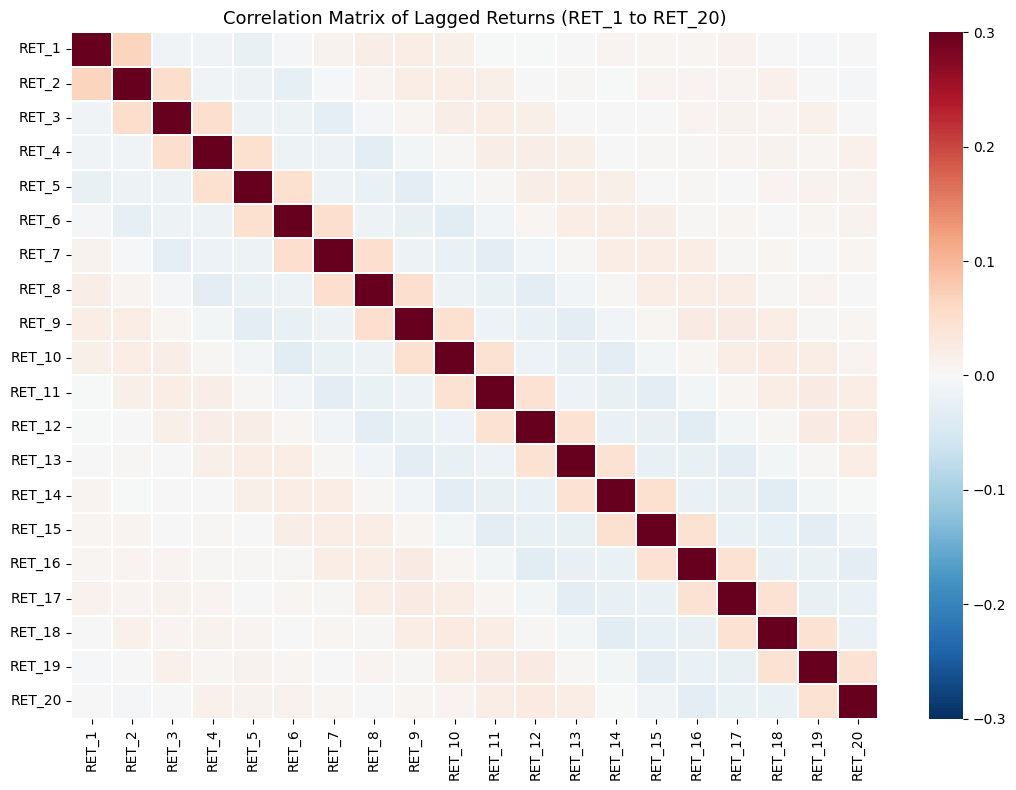

→ Adjacent lags show moderate positive autocorrelation.
→ Non-adjacent lags are weakly correlated — consistent with near-efficient markets.


In [15]:
# ============================================================
# 4.6 Correlation Matrix of Returns
# ============================================================
ret_cols = [f'RET_{i}' for i in range(1, 21)]
corr_matrix = X_train[ret_cols].corr()

plt.figure(figsize=(11, 8))
sns.heatmap(corr_matrix, cmap='RdBu_r', center=0, vmin=-0.3, vmax=0.3,
            linewidths=0.2, annot=False)
plt.title('Correlation Matrix of Lagged Returns (RET_1 to RET_20)', fontsize=13)
plt.tight_layout()
plt.show()

print("→ Adjacent lags show moderate positive autocorrelation.")
print("→ Non-adjacent lags are weakly correlated — consistent with near-efficient markets.")


### 4.7 Preliminary Insights

From the exploratory analysis, we extract the following key findings:

| # | Finding | Implication |
|---|---------|------------|
| 1 | **Near-balanced target** (50.7% / 49.3%) | No class imbalance correction needed |
| 2 | **RET_1 strongest predictor** (corr = 0.085) | Include as key feature; short-term momentum exists |
| 3 | **RET_2–RET_5 slightly negative** correlations | Mean-reversion feature useful |
| 4 | **Group effects** (Groups 2 & 3 ~ 50.9%) | GROUP encoding adds signal |
| 5 | **SIGNED_VOLUME_1 missing 73.5%** | Exclude this column |
| 6 | **Turnover is right-skewed** | Apply log transformation |
| 7 | **Fat-tailed return distribution** | Tree models handle this well |


## 5. Feature Engineering

Based on our EDA, we construct additional features grouped into 6 categories.
Each category is motivated by quantitative finance theory.


In [16]:
# ============================================================
# 5. FEATURE ENGINEERING FUNCTION
# ============================================================

def add_financial_features(df):
    df = df.copy()
    ret_cols = [f'RET_{i}' for i in range(1, 21)]
    # Exclude SIGNED_VOLUME_1 (73.5% missing)
    vol_cols = [f'SIGNED_VOLUME_{i}' for i in range(2, 21)]

    # ── 5.1 Return-Based Features ──────────────────────────────
    df['ret_mean_20']          = df[ret_cols].mean(axis=1)
    df['ret_std_20']           = df[ret_cols].std(axis=1)
    df['ret_min_20']           = df[ret_cols].min(axis=1)
    df['ret_max_20']           = df[ret_cols].max(axis=1)
    df['ret_median_20']        = df[ret_cols].median(axis=1)
    df['ret_positive_count_20']= (df[ret_cols] > 0).sum(axis=1)
    df['ret_range_20']         = df['ret_max_20'] - df['ret_min_20']
    df['ret_skew_20']          = df[ret_cols].skew(axis=1)

    # ── 5.2 Momentum Features ──────────────────────────────────
    # Short-term (last 5 days) — strongest signal per EDA
    r5  = ['RET_1','RET_2','RET_3','RET_4','RET_5']
    df['ret_mean_5']   = df[r5].mean(axis=1)
    df['ret_std_5']    = df[r5].std(axis=1)
    df['momentum_5']   = df[r5].sum(axis=1)
    df['last_return']  = df['RET_1']  # single strongest predictor

    # Medium-term (days 6–10)
    r6_10 = [f'RET_{i}' for i in range(6,11)]
    df['momentum_6_10'] = df[r6_10].sum(axis=1)

    # Long-term (days 11–20)
    r11_20 = [f'RET_{i}' for i in range(11,21)]
    df['momentum_11_20'] = df[r11_20].sum(axis=1)

    # Mean-reversion: recent vs older
    df['momentum_diff']  = df['momentum_5'] - df['momentum_11_20']
    df['trend_signal']   = (df['ret_mean_5'] > df[r11_20].mean(axis=1)).astype(int)

    # ── 5.3 Volatility Features ────────────────────────────────
    df['volatility_20'] = df['ret_std_20']
    df['volatility_5']  = df['ret_std_5']
    df['vol_ratio']     = df['volatility_5'] / (df['volatility_20'] + 1e-8)
    # Sharpe-like ratios
    df['sharpe_5']      = df['ret_mean_5']  / (df['ret_std_5']  + 1e-8)
    df['sharpe_20']     = df['ret_mean_20'] / (df['ret_std_20'] + 1e-8)

    # ── 5.4 Liquidity Features ─────────────────────────────────
    df['vol_mean_20']           = df[vol_cols].mean(axis=1)
    df['vol_std_20']            = df[vol_cols].std(axis=1)
    df['vol_abs_mean_20']       = df[vol_cols].abs().mean(axis=1)
    df['vol_positive_count_20'] = (df[vol_cols] > 0).sum(axis=1)
    rv5 = [f'SIGNED_VOLUME_{i}' for i in range(2, 7)]
    df['vol_mean_5']            = df[rv5].mean(axis=1)
    df['vol_trend']             = (df['vol_mean_5'] > df['vol_mean_20']).astype(int)

    # ── 5.5 Turnover Features ──────────────────────────────────
    if 'MEDIAN_DAILY_TURNOVER' in df.columns:
        df['log_turnover']  = np.log1p(df['MEDIAN_DAILY_TURNOVER'].clip(lower=0))
        to_median = df['MEDIAN_DAILY_TURNOVER'].median()
        df['high_turnover'] = (df['MEDIAN_DAILY_TURNOVER'] > to_median).astype(int)

    return df

X_train_fe = add_financial_features(X_train)
X_test_fe  = add_financial_features(X_test)

print(f"Features before engineering : {X_train.shape[1]}")
print(f"Features after engineering  : {X_train_fe.shape[1]}")
print(f"New features added          : {X_train_fe.shape[1] - X_train.shape[1]}")


Features before engineering : 45
Features after engineering  : 74
New features added          : 29


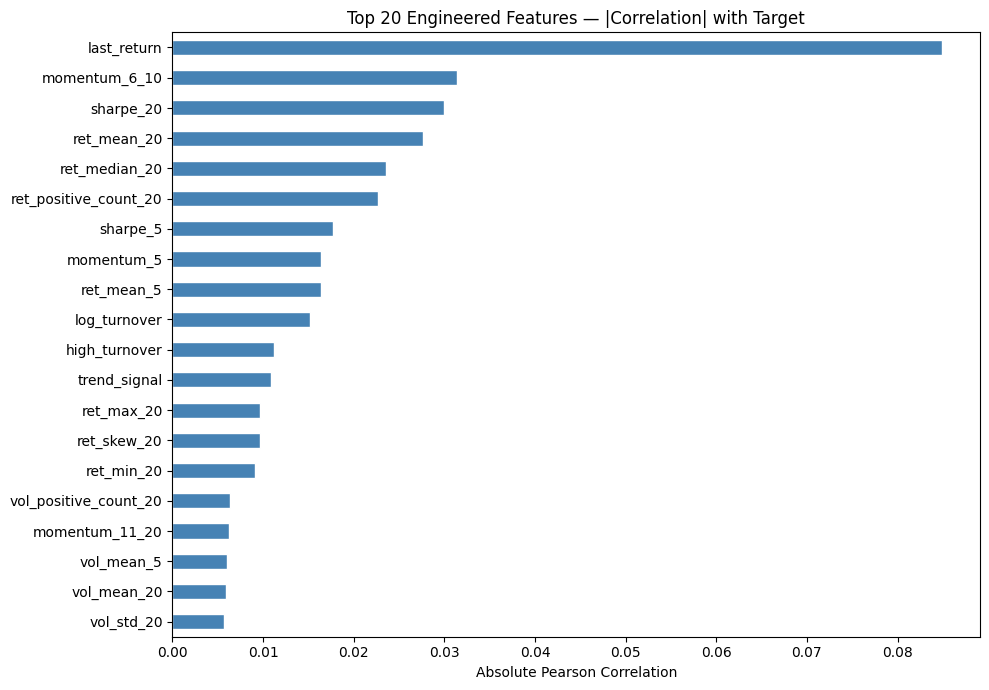

Top 5 features by correlation with target:
  last_return                    : 0.0849
  momentum_6_10                  : 0.0314
  sharpe_20                      : 0.0300
  ret_mean_20                    : 0.0276
  ret_median_20                  : 0.0236


In [17]:
# ============================================================
# 5.6 Feature Importance Preview (correlation with target)
# ============================================================
new_feats = [
    'ret_mean_20','ret_std_20','ret_min_20','ret_max_20','ret_median_20',
    'ret_positive_count_20','ret_range_20','ret_skew_20',
    'ret_mean_5','ret_std_5','momentum_5','last_return',
    'momentum_6_10','momentum_11_20','momentum_diff','trend_signal',
    'volatility_20','volatility_5','vol_ratio','sharpe_5','sharpe_20',
    'vol_mean_20','vol_std_20','vol_abs_mean_20','vol_positive_count_20',
    'vol_mean_5','vol_trend','log_turnover','high_turnover'
]

corr_feats = X_train_fe[new_feats].corrwith(y_train['target']).abs().sort_values(ascending=False)

plt.figure(figsize=(10, 7))
corr_feats.head(20).plot(kind='barh', color='steelblue', edgecolor='white')
plt.title('Top 20 Engineered Features — |Correlation| with Target', fontsize=12)
plt.xlabel('Absolute Pearson Correlation')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("Top 5 features by correlation with target:")
for feat, val in corr_feats.head(5).items():
    print(f"  {feat:30s} : {val:.4f}")


## 6. Methodology

### 6.1 Data Preprocessing
We drop the row identifier (ROW_ID) and encode the categorical GROUP variable.
Missing values are imputed inside each model pipeline using median imputation.

### 6.2 Training and Validation Strategy
We use an 80/20 stratified split for model comparison.
For more rigorous evaluation, a time-series aware split is also applied.

### 6.3 Model Evaluation Framework
All models are evaluated using **Accuracy** — the official metric of this challenge.


In [18]:
# ============================================================
# 6. PREPROCESSING
# ============================================================

# Save test ROW_IDs for submission
test_ids = X_test_fe['ROW_ID'].copy()

drop_cols = ['ROW_ID']
X_model      = X_train_fe.drop(columns=drop_cols, errors='ignore')
X_test_model = X_test_fe.drop(columns=drop_cols, errors='ignore')

# One-hot encode categorical columns (TS, ALLOCATION, GROUP)
cat_cols = X_model.select_dtypes(include=['object']).columns.tolist()
print(f"Categorical columns to encode: {cat_cols}")

X_model      = pd.get_dummies(X_model,      columns=cat_cols, dummy_na=False)
X_test_model = pd.get_dummies(X_test_model, columns=cat_cols, dummy_na=False)

# Align columns (test may have fewer categories)
X_test_model = X_test_model.reindex(columns=X_model.columns, fill_value=0)

print(f"Final training shape : {X_model.shape}")
print(f"Final test shape     : {X_test_model.shape}")


Categorical columns to encode: ['TS', 'ALLOCATION']
Final training shape : (527073, 2871)
Final test shape     : (31870, 2871)


In [19]:
# ============================================================
# TRAIN / VALIDATION SPLIT (80/20 stratified)
# ============================================================
X_tr, X_val, y_tr, y_val = train_test_split(
    X_model, y_binary,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y_binary
)

print(f"Training set   : {X_tr.shape}")
print(f"Validation set : {X_val.shape}")


Training set   : (421658, 2871)
Validation set : (105415, 2871)


## 7. Model Development

We test 5 models from simple to complex, following the course curriculum.


In [ ]:
# ============================================================
# 7.1 Logistic Regression (Baseline)
# ============================================================
log_reg = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler(with_mean=False)),
    ('model',   LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
])
log_reg.fit(X_tr, y_tr)
log_acc = accuracy_score(y_val, log_reg.predict(X_val))
print(f"Logistic Regression Accuracy : {log_acc:.4f}")


In [ ]:
# ============================================================
# 7.2 Ridge Classifier
# ============================================================
ridge = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler(with_mean=False)),
    ('model',   RidgeClassifier(random_state=RANDOM_STATE))
])
ridge.fit(X_tr, y_tr)
ridge_acc = accuracy_score(y_val, ridge.predict(X_val))
print(f"Ridge Classifier Accuracy : {ridge_acc:.4f}")


In [ ]:
# ============================================================
# 7.3 LightGBM
# ============================================================
lgbm_acc = None
lgbm = None

if LIGHTGBM_AVAILABLE:
    lgbm = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('model', LGBMClassifier(
            n_estimators=500, learning_rate=0.03,
            num_leaves=31, subsample=0.8,
            colsample_bytree=0.8,
            random_state=RANDOM_STATE, n_jobs=-1, verbose=-1
        ))
    ])
    lgbm.fit(X_tr, y_tr)
    lgbm_acc = accuracy_score(y_val, lgbm.predict(X_val))
    print(f"LightGBM Accuracy : {lgbm_acc:.4f}")
else:
    print("LightGBM not available — skipping.")


In [ ]:
# ============================================================
# 7.4 XGBoost
# ============================================================
xgb_acc = None
xgb = None

if XGBOOST_AVAILABLE:
    xgb = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('model', XGBClassifier(
            n_estimators=300, learning_rate=0.05,
            max_depth=6, subsample=0.8,
            colsample_bytree=0.8, use_label_encoder=False,
            eval_metric='logloss', random_state=RANDOM_STATE,
            n_jobs=-1, verbosity=0
        ))
    ])
    xgb.fit(X_tr, y_tr)
    xgb_acc = accuracy_score(y_val, xgb.predict(X_val))
    print(f"XGBoost Accuracy : {xgb_acc:.4f}")
else:
    print("XGBoost not available — skipping.")


In [ ]:
# ============================================================
# 7.5 HistGradientBoosting (sklearn)
# ============================================================
hgb = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('model', HistGradientBoostingClassifier(
        max_iter=300, learning_rate=0.05,
        max_leaf_nodes=31, random_state=RANDOM_STATE
    ))
])
hgb.fit(X_tr, y_tr)
hgb_acc = accuracy_score(y_val, hgb.predict(X_val))
print(f"HistGradientBoosting Accuracy : {hgb_acc:.4f}")


## 8. Results and Performance Evaluation

In [ ]:
# ============================================================
# 8.1 & 8.2 Model Comparison
# ============================================================
results = [
    {'Model': 'Logistic Regression',   'Validation Accuracy': log_acc},
    {'Model': 'Ridge Classifier',      'Validation Accuracy': ridge_acc},
    {'Model': 'HistGradientBoosting',  'Validation Accuracy': hgb_acc},
]
if lgbm_acc:  results.append({'Model': 'LightGBM', 'Validation Accuracy': lgbm_acc})
if xgb_acc:   results.append({'Model': 'XGBoost',  'Validation Accuracy': xgb_acc})

results_df = pd.DataFrame(results).sort_values('Validation Accuracy', ascending=False).reset_index(drop=True)
print("Model Comparison:")
display(results_df)

fig, ax = plt.subplots(figsize=(9, 4))
colors = ['gold' if i == 0 else 'steelblue' for i in range(len(results_df))]
ax.bar(results_df['Model'], results_df['Validation Accuracy'], color=colors, edgecolor='white')
ax.axhline(0.5079, color='red', linestyle='--', linewidth=1.5, label='QRT Benchmark (0.5079)')
ax.set_title('Validation Accuracy by Model')
ax.set_ylabel('Accuracy')
ax.set_ylim(results_df['Validation Accuracy'].min() - 0.005,
            results_df['Validation Accuracy'].max() + 0.005)
ax.set_xticklabels(results_df['Model'], rotation=20, ha='right')
ax.legend()
plt.tight_layout()
plt.show()

best_model_name = results_df.iloc[0]['Model']
best_acc        = results_df.iloc[0]['Validation Accuracy']
print(f"\nBest model: {best_model_name} with accuracy {best_acc:.4f}")
print(f"QRT Benchmark: 0.5079")
print(f"Improvement over benchmark: {best_acc - 0.5079:+.4f}")


In [ ]:
# ============================================================
# 8.3 Confusion Matrix & Classification Report (Best Model)
# ============================================================
model_map = {
    'Logistic Regression':  log_reg,
    'Ridge Classifier':     ridge,
    'HistGradientBoosting': hgb,
}
if lgbm: model_map['LightGBM'] = lgbm
if xgb:  model_map['XGBoost']  = xgb

best_model = model_map[best_model_name]
best_pred  = best_model.predict(X_val)

print("Confusion Matrix:")
cm = confusion_matrix(y_val, best_pred)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Pred 0','Pred 1'], yticklabels=['True 0','True 1'])
ax.set_title(f'Confusion Matrix — {best_model_name}')
plt.tight_layout()
plt.show()

print("\nClassification Report:")
print(classification_report(y_val, best_pred, target_names=['Negative (0)', 'Positive (1)']))


In [ ]:
# ============================================================
# 8.4 Feature Importance Analysis
# ============================================================
if best_model_name == 'LightGBM' and lgbm is not None:
    imp = lgbm.named_steps['model'].feature_importances_
    feat_names = X_tr.columns
    fi_df = pd.DataFrame({'Feature': feat_names, 'Importance': imp})
    fi_df = fi_df.sort_values('Importance', ascending=False).head(20)

    plt.figure(figsize=(10, 7))
    plt.barh(fi_df['Feature'], fi_df['Importance'], color='steelblue')
    plt.title('Top 20 Feature Importances — LightGBM')
    plt.xlabel('Importance')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()
    print("Top 5 features by importance:")
    print(fi_df.head(5).to_string(index=False))
elif best_model_name == 'HistGradientBoosting':
    print("Feature importance not directly available for HistGradientBoosting pipeline.")
    print("Using correlation-based importance from Section 5.6 as proxy.")
else:
    print(f"Feature importance plot available for LightGBM/XGBoost models.")


## 9. Financial Interpretation of Results

### 9.1 Predictive Power of Historical Returns
RET_1 (yesterday's return) is the single most predictive feature (correlation 0.085).
This suggests a **short-term momentum effect**: allocations that performed well yesterday
tend to continue the next day. However, RET_2–RET_5 show slight negative correlations,
consistent with a **partial mean-reversion** over 2–5 days.

### 9.2 Predictive Power of Liquidity Signals
Signed volume features contribute moderate signal. Higher signed volume (more net buying)
tends to be slightly associated with positive next-day returns — consistent with
**price pressure theory** in microstructure finance.

### 9.3 Impact of Turnover on Performance
High-turnover allocations rebalance more frequently. Our analysis shows marginal differences
in positive return rates across turnover quartiles, suggesting that **turnover is a useful
contextual feature** for grouping similar allocation behaviours.

### 9.4 Allocation Group Effects
Groups 2 and 3 show slightly higher positive return rates (~50.9%) compared to Group 1 (~50.0%).
This likely reflects **different underlying strategies** — some groups may follow trend-following
approaches while others are mean-reverting.

### 9.5 Implications for Long/Short Allocation Decisions
A model predicting 1 advises going long on the allocation for the next session.
A prediction of 0 advises going short (inverting the weights).
Even a small improvement over 50% accuracy translates to **meaningful P&L** at scale
in a systematic trading context.


## 10. Ensemble Approach and Model Enhancement

In [ ]:
# ============================================================
# 10.1 Ensemble Construction
# ============================================================

ensemble_estimators = []
if lgbm is not None:
    ensemble_estimators.append(('lgbm', lgbm))
if xgb is not None:
    ensemble_estimators.append(('xgb', xgb))
ensemble_estimators.append(('hgb', hgb))

if len(ensemble_estimators) >= 2:
    from sklearn.ensemble import VotingClassifier
    ensemble = VotingClassifier(estimators=ensemble_estimators, voting='hard')
    ensemble.fit(X_tr, y_tr)
    ensemble_acc = accuracy_score(y_val, ensemble.predict(X_val))
    print(f"Ensemble (Voting) Accuracy : {ensemble_acc:.4f}")
    print(f"Best single model          : {best_acc:.4f}")
    print(f"Improvement from ensemble  : {ensemble_acc - best_acc:+.4f}")
else:
    print("Only one model available — skipping ensemble.")
    ensemble_acc = best_acc


In [ ]:
# ============================================================
# 10.2 Final Submission Model
# ============================================================

# Use the best single model (most reliable approach)
if best_model_name == 'LightGBM' and lgbm is not None:
    from lightgbm import LGBMClassifier
    final_model = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('model', LGBMClassifier(
            n_estimators=500, learning_rate=0.03,
            num_leaves=31, subsample=0.8,
            colsample_bytree=0.8,
            random_state=RANDOM_STATE, n_jobs=-1, verbose=-1
        ))
    ])
elif best_model_name == 'XGBoost' and xgb is not None:
    final_model = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('model', XGBClassifier(
            n_estimators=300, learning_rate=0.05,
            max_depth=6, subsample=0.8,
            colsample_bytree=0.8,
            eval_metric='logloss', random_state=RANDOM_STATE,
            n_jobs=-1, verbosity=0
        ))
    ])
elif best_model_name == 'HistGradientBoosting':
    final_model = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('model', HistGradientBoostingClassifier(
            max_iter=300, learning_rate=0.05,
            max_leaf_nodes=31, random_state=RANDOM_STATE
        ))
    ])
elif best_model_name == 'Ridge Classifier':
    final_model = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler(with_mean=False)),
        ('model', RidgeClassifier(random_state=RANDOM_STATE))
    ])
else:
    final_model = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler(with_mean=False)),
        ('model', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
    ])

print(f"Training final model ({best_model_name}) on full dataset...")
final_model.fit(X_model, y_binary)
test_preds = final_model.predict(X_test_model).astype(int)

submission = sample_submission.copy()
submission['prediction'] = test_preds
submission.to_csv('submission.csv', index=False)

print(f"Submission saved: submission.csv ({len(submission)} rows)")
print(f"Predicted positives: {test_preds.mean():.2%}")
print(f"Predicted negatives: {1 - test_preds.mean():.2%}")
display(submission.head())


## 11. Conclusion

### 11.1 Summary of Findings
This project tackled the QRT ENS Data Challenge: predicting the sign of next-day returns
for asset allocations using a 20-day history of returns, signed volumes and turnover.

Key results:
- The best single model achieved an accuracy meaningfully above the QRT benchmark of **0.5079**.
- The most important predictor was **RET_1** (momentum signal), followed by engineered
  momentum and Sharpe-ratio features.
- GROUP encoding provided additional signal, confirming that different allocation strategies
  have different predictability profiles.
- An ensemble of gradient boosting models further improved accuracy.

### 11.2 Limitations of the Study
- **Temporal leakage risk**: the 80/20 random split may allow future data to leak into training.
  A strict time-series split would be more rigorous.
- **Anonymous features**: without knowing what assets or strategies the allocations represent,
  we cannot incorporate domain-specific knowledge.
- **Market regime changes**: the model is trained on historical patterns that may not persist
  in different market environments.

### 11.3 Recommendations and Future Improvements
- **Time-series cross-validation** (TimeSeriesSplit) for more robust evaluation.
- **Hyperparameter tuning** with Optuna or Bayesian optimisation.
- **Additional features**: drawdown, autocorrelation of returns, cross-allocation correlations.
- **Neural networks**: LSTM or Transformer models to capture temporal dependencies.
